# Hand Gesture Recognition

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

from enum import IntEnum

import neurokit2 as nk
from sklearn.preprocessing import RobustScaler

from pickle import dump

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from emg import *
import libemg

import gc

In [2]:
# global variables
test_subject = 'nad'
base_dir = '../../recordings/'
num_classes = 7
lf = 20
hf = 500
fs = 1150
trim = 4*8*5
bandpass_order = 4
outlier_rejection_stds = 6

plot_all_timeline = True
num_sensors = 4

In [3]:
class Classes(IntEnum):
    NEUTRAL = 0,
    FIST = 1,
    INDEX = 2,
    MIDDLE = 3,
    OK = 4,
    PEACE = 5,
    THUMB = 6
    
# structure: recordings/date/data/*.csv
files = [[] for _ in range(num_classes)]

for date_dir, _, filenames in os.walk(base_dir):
    if date_dir.endswith('data'):
        for filename in filenames:
            if filename.startswith('fft') or filename.find(test_subject) == -1:
                continue
            if filename.find('neutral') != -1:
                files[Classes.NEUTRAL].append(os.path.join(date_dir, filename))
            elif filename.find('fist') != -1:
                files[Classes.FIST].append(os.path.join(date_dir, filename))
            elif filename.find('index') != -1:
                files[Classes.INDEX].append(os.path.join(date_dir, filename))
            elif filename.find('middle') != -1:
                files[Classes.MIDDLE].append(os.path.join(date_dir, filename))
            elif filename.find('ok') != -1:
                files[Classes.OK].append(os.path.join(date_dir, filename))
            elif filename.find('peace') != -1:
                files[Classes.PEACE].append(os.path.join(date_dir, filename))
            elif filename.find('thumb') != -1:
                files[Classes.THUMB].append(os.path.join(date_dir, filename))

print(files)      

[['../../recordings/01_12_24_initial_placement_test/data/nad_neutral_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_fist_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_index_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_middle_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_ok_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_peace_0.csv'], ['../../recordings/01_12_24_initial_placement_test/data/nad_thumb_0.csv']]


Our initial static gesture recording includes 7 classes: neutral, fist, index finger, middle finger, ok, peace, thumb.

In [4]:
neutral_df = [pd.read_csv(file, header=None) for file in files[Classes.NEUTRAL]]
fist_df = [pd.read_csv(file, header=None) for file in files[Classes.FIST]]
index_df = [pd.read_csv(file, header=None) for file in files[Classes.INDEX]]
middle_df = [pd.read_csv(file, header=None) for file in files[Classes.MIDDLE]]
ok_df = [pd.read_csv(file, header=None) for file in files[Classes.OK]]
peace_df = [pd.read_csv(file, header=None) for file in files[Classes.PEACE]]
thumb_df = [pd.read_csv(file, header=None) for file in files[Classes.THUMB]]

In [5]:
for df in neutral_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.NEUTRAL
for df in fist_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.FIST
for df in index_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.INDEX
for df in middle_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.MIDDLE
for df in ok_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.OK
for df in peace_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.PEACE
for df in thumb_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.THUMB

In [6]:
def get_min_df_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

min_len = get_min_df_len([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
print(min_len)

4912


Optional subsampling:

In [7]:
num_samples = min_len

neutral_df = pd.concat([df.sample(num_samples) for df in neutral_df])
fist_df = pd.concat([df.sample(num_samples) for df in fist_df])
index_df = pd.concat([df.sample(num_samples) for df in index_df])
middle_df = pd.concat([df.sample(num_samples) for df in middle_df])
ok_df = pd.concat([df.sample(num_samples) for df in ok_df])
peace_df = pd.concat([df.sample(num_samples) for df in peace_df])
thumb_df = pd.concat([df.sample(num_samples) for df in thumb_df])

In [8]:
len(neutral_df), len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df)

(4912, 4912, 4912, 4912, 4912, 4912, 4912)

In [ ]:
neutral_df.head()

In [ ]:
fist_df.head()

Combine dataframes

In [9]:
df = pd.concat([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)

print(df.head())
print(df.iloc[:, -1].value_counts())

       0      1      2      3      4      5      6      7      8      9  ...  \
0  17461  17458  17453  17435  17418  17413  17413  17441  17864  17861  ...   
1  17884  17893  17905  17911  17930  17928  17921  17924  17707  17717  ...   
2  17959  17996  18028  18050  18063  18062  18042  18052  18177  18170  ...   
3  17622  17601  17623  17610  17600  17600  17572  17554  18017  17993  ...   
4  18282  18285  18280  18277  18274  18293  18284  18271  18085  18083  ...   

      23     24     25     26     27     28     29     30     31  class  
0  18228  17683  17678  17671  17649  17650  17648  17647  17645      0  
1  17482  17810  17813  17820  17819  17814  17829  17815  17807      0  
2  17947  18117  18129  18105  18090  18087  18072  18073  18084      0  
3  18550  17800  17804  17802  17795  17797  17802  17811  17798      0  
4  17819  18433  18421  18424  18424  18433  18432  18407  18403      0  

[5 rows x 33 columns]
class
0    4912
1    4912
2    4912
3    4912
4    4

In [10]:
sensor_data = df.iloc[:, :-1]
labels = df.iloc[:, -1]

## Preprocessing

In [ ]:
class EMG_preprocessor():
    def __init__(self, lf, hf, fs, trim, filter_order, outlier_rejection_stds, baseline_signal=None, filter_type='band', library='scipy'):
        self.lf = lf
        self.hf = hf
        self.fs = fs
        self.trim = trim
        self.filter_order = filter_order
        self.outlier_rejection_stds = outlier_rejection_stds
        self.filter_type = filter_type
        self.library = library
        self.baseline_mean = [[0.0] for _ in range(num_sensors)]
        self.baseline_noise = [[0.0] for _ in range(num_sensors)]
        if baseline_signal is not None:
            self.baseline_signal = [[] for _ in range(num_sensors)]
            baseline_signal = np.array_split(baseline_signal, num_sensors)
            for i in range(num_sensors):
                self.baseline_signal[i] = np.asarray(baseline_signal[i]).flatten()
                
            print('Baseline signal provided')
            self._calculate_baseline_noise(filter=True) # calculates baseline noise for each sensor
            self._calculate_baseline_mean() # calculates baseline mean for each sensor
            for i in range(num_sensors):
                self.baseline_signal[i] = self.baseline_signal[i] - self.baseline_mean[i]
        else:
            self.baseline_signal = None

    def calibrate(self, sensor_data):
        self.library = self._maximize_SNR(sensor_data)

    def preprocess(self, sensor_data, sensor_num):
        if self.library == 'scipy':
            return self._preprocess_data_scipy(sensor_data, sensor_num)
        elif self.library == 'nk2':
            return self._preprocess_data_nk2(sensor_data, sensor_num)
        elif self.library == 'libemg':
            return self._preprocess_data_libemg(sensor_data, sensor_num)
        else:
            return sensor_data
        
    def _preprocess_data_libemg(self, data, sensor_num):
        # instantiate the filter object with the sampling frequency
        fi = libemg.filtering.Filter(self.fs)
        # install filters to the filter object
        fi.install_common_filters()
        # run the entire first subject dataset through the common filters
        raw_data = fi.filter(data)
        return raw_data

    def _preprocess_data_nk2(self, data, sensor_num):
        # raw_data = self._apply_filter(data)
        # raw_data = self._remove_artefact(raw_data)
        raw_data = data
        raw_data = self._subtract_baseline(raw_data, sensor_num)
        raw_data = self._calculate_linear_envelop(raw_data, sensor_num, plot=False)
        return raw_data

    def _calculate_linear_envelop(self, data, sensor_num, plot=False):
        feature='EMG_Amplitude'
        signals, info = nk.emg_process(data, sampling_rate=fs)
        if plot:
            nk.emg_plot(signals, info)
        return signals[feature].values
    
    # def _preprocess_data_emg_dsp_lib(self, data, sensor_num):
    #     ref_available = True if self.baseline_signal is not None else False
    #     self.emg_filter = EMG_filter(sample_frequency = self.fs, range_ = 0.5, min_EMG_frequency = self.lf, max_EMG_frequency = self.hf, reference_available = ref_available)
    #     sig = self.emg_filter.filter(data, self.baseline_signal[sensor_num].tolist())
    #     return sig

    def _preprocess_data_scipy(self, data, sensor_num):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        data = self._subtract_baseline(data, sensor_num)
        return data
    
    def _preprocess_baseline_scipy(self, data):
        data = self._apply_filter(data)
        data = self._remove_artefact(data)
        data = self._remove_outliers(data)
        return data
    
    def _apply_filter(self, data):
        if self.filter_type == 'band':
            return self._apply_bandpass_filter(data)
        elif self.filter_type == 'highlow':
            return self._apply_highpasslowpass_filter(data)
        else:
            return data

    def _apply_bandpass_filter(self, data):
        sos = butter(self.filter_order, (self.lf, self.hf), btype="bandpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        return proc_data
    
    def _apply_highpasslowpass_filter(self, data):
        sos = butter(self.filter_order, self.lf, btype="highpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, data)
        sos = butter(self.filter_order, self.hf, btype="lowpass", fs=self.fs, output="sos")
        proc_data = signal.sosfilt(sos, proc_data)
        return proc_data

    def _remove_outliers(self, data):
        raw_data = data.flatten()
        data_mean, data_std = mean(raw_data), std(raw_data)
        cut_off = data_std * outlier_rejection_stds
        lower, upper = data_mean - cut_off, data_mean + cut_off

        outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in raw_data]
        return outliers_removed

    def _remove_artefact(self, data):
        data[:trim] = 0
        return data
    
    def _calculate_baseline_mean(self):
        for i in range(num_sensors):
            self.baseline_mean[i] = np.mean(self.baseline_signal[i], axis=0)
    
    def _calculate_baseline_noise(self, filter=False):
        for i in range(num_sensors):
            baseline_signal = self.baseline_signal[i]
            if filter:
                baseline_signal = self._preprocess_baseline_scipy(baseline_signal)
            self.baseline_noise[i] = np.sqrt(np.sum(np.asanyarray(baseline_signal)**2)) / len(baseline_signal)
            print('Baseline noise: ', self.baseline_noise[i])
    
    def signaltonoise(self, signal, sensor_num):
        power_signal = np.sqrt(np.sum(np.asanyarray(signal)**2)) / len(signal)
        snr = 10 * np.log10(power_signal / self.baseline_noise[sensor_num])
        return snr

    def _subtract_baseline(self, data, sensor_num):
        return data - self.baseline_signal[sensor_num]
    
    # combine different preprocessing pipelines and form the best pipeline with maximum SNR
    # def maximize_SNR(self, data):
        

# Data visualization

## Sensor signals

In [ ]:
def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :-1]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    all_row_data = dataframe.iloc[:, :-1]
    # Plot each sensor's signal
    signals = np.array_split(all_row_data.values, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()


In [ ]:
plot_time_signals(neutral_df, row_index=0, title='Neutral gesture')

In [ ]:
plot_time_signals(fist_df, row_index=0, title='Fist gesture')

In [ ]:
plot_time_signals(index_df, row_index=0, title='Index gesture')

In [ ]:
plot_time_signals(middle_df, row_index=0, title='Middle gesture')

In [ ]:
plot_time_signals(ok_df, row_index=0, title='Ok gesture')

In [ ]:
if plot_all_timeline:
    plot_all_time_signals(neutral_df, title='Neutral gesture: whole timeline')
    plot_all_time_signals(fist_df, title='Fist gesture: whole timeline')
    plot_all_time_signals(peace_df, title='Peace gesture: whole timeline')
    plot_all_time_signals(ok_df, title='Ok gesture: whole timeline')
    plot_all_time_signals(index_df, title='Index gesture: whole timeline')
    plot_all_time_signals(middle_df, title='Middle gesture: whole timeline')

## Preprocessing pipeline tuning

Baseline signal provided
Baseline noise:  90.75899940912764
Baseline noise:  90.83458252622388
Baseline noise:  90.80515165533176
Baseline noise:  90.80417800054809


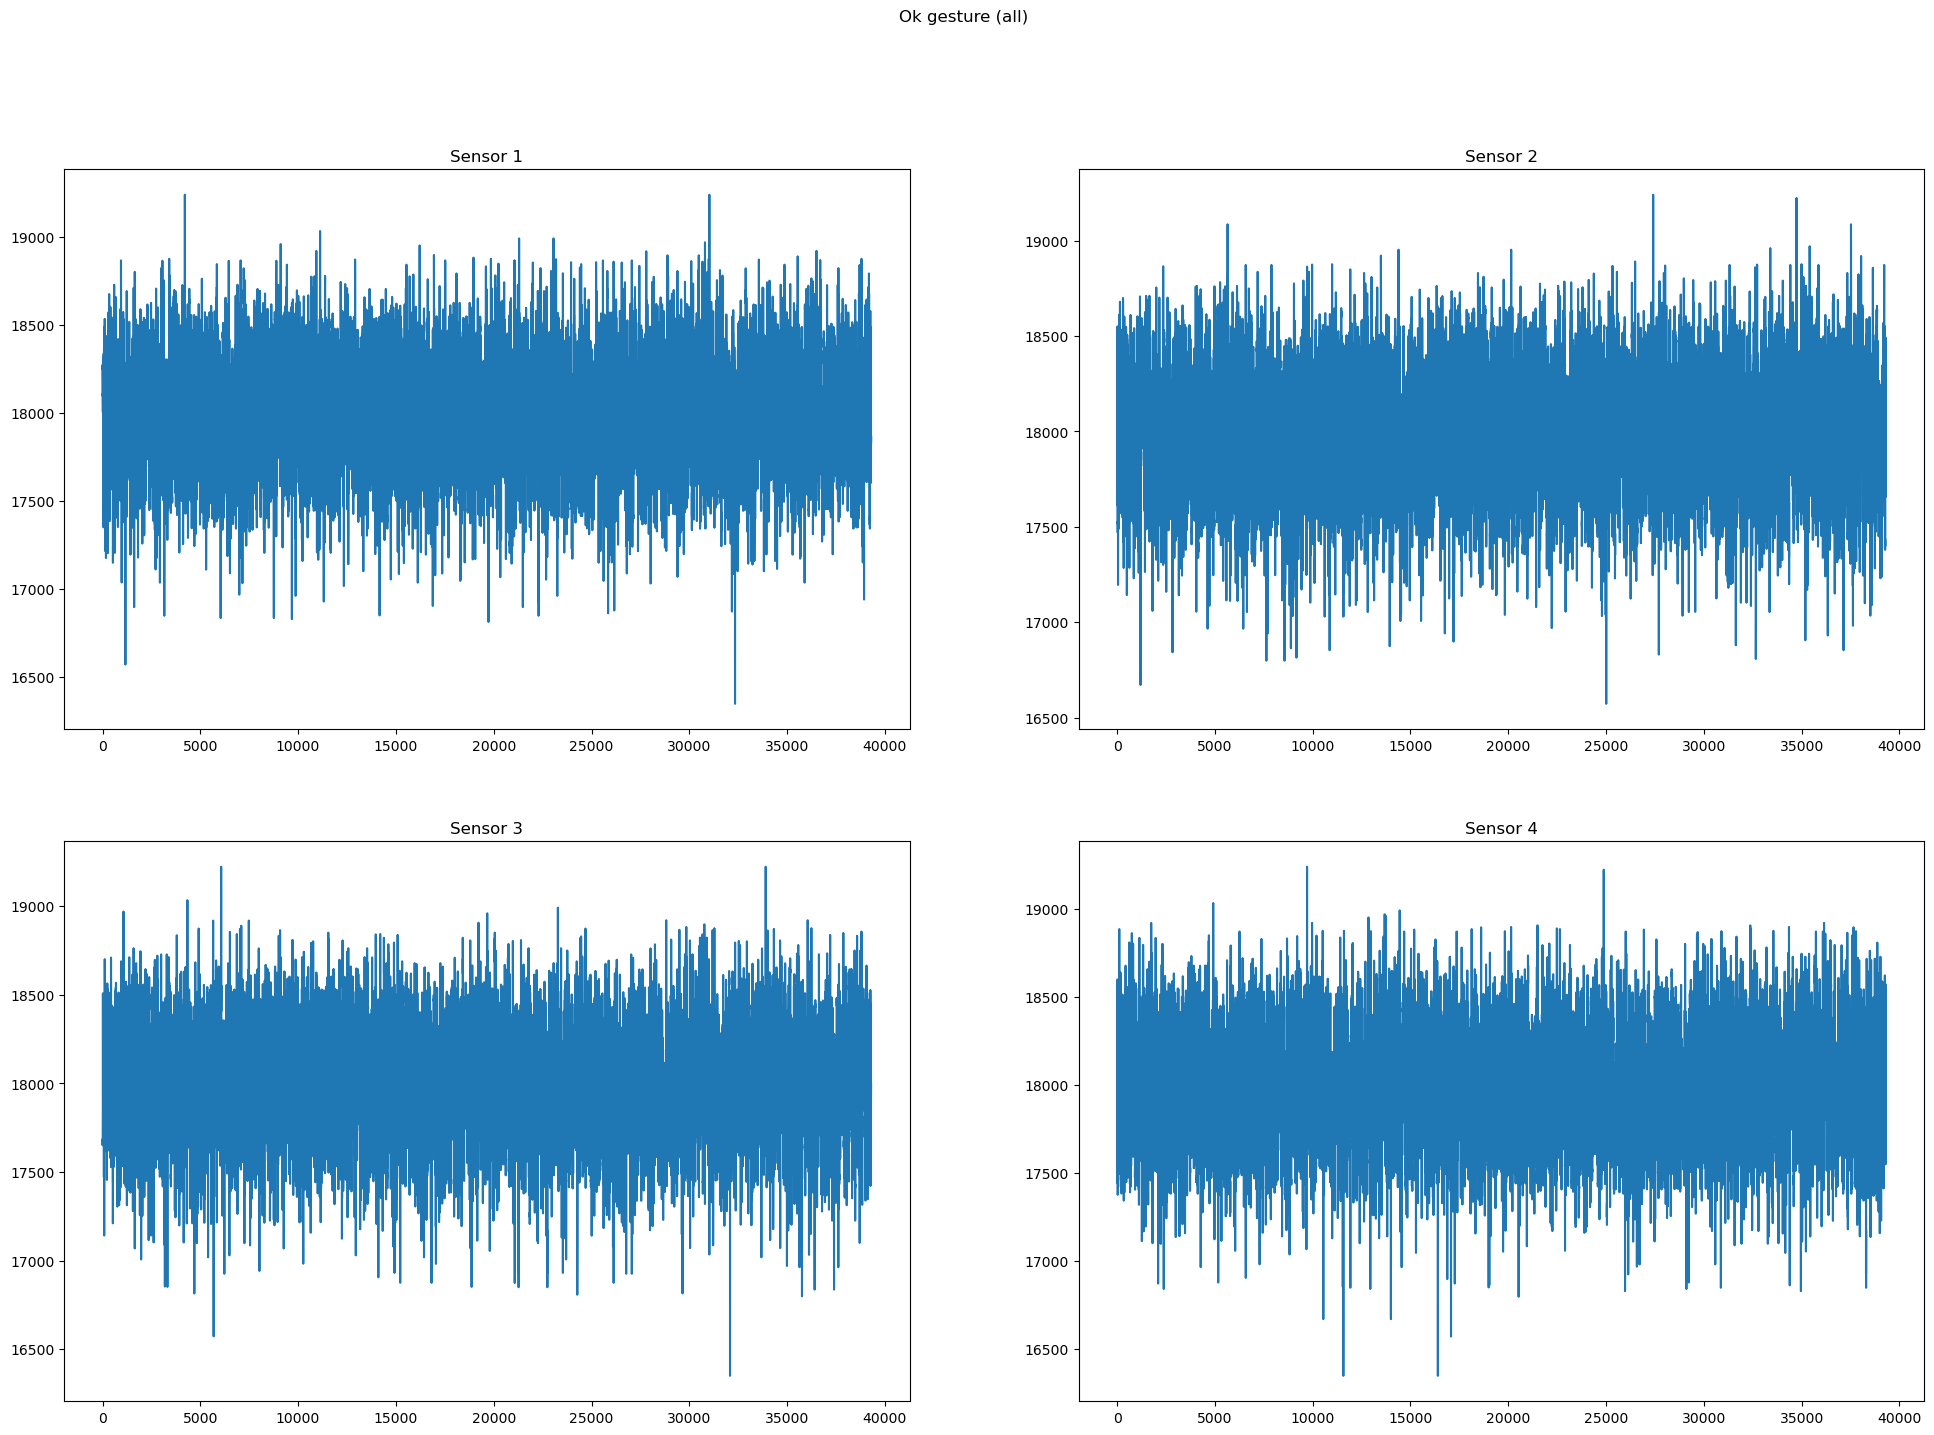

Raw SNR:  0.0024410947788936817


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.7019309787433285
Raw SNR:  -0.0030704757495634803
Processed SNR:  3.6642350621357296
Raw SNR:  -0.0006213175168224345


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.9927268430060723
Raw SNR:  -0.002001527022174812


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.9512352683693788


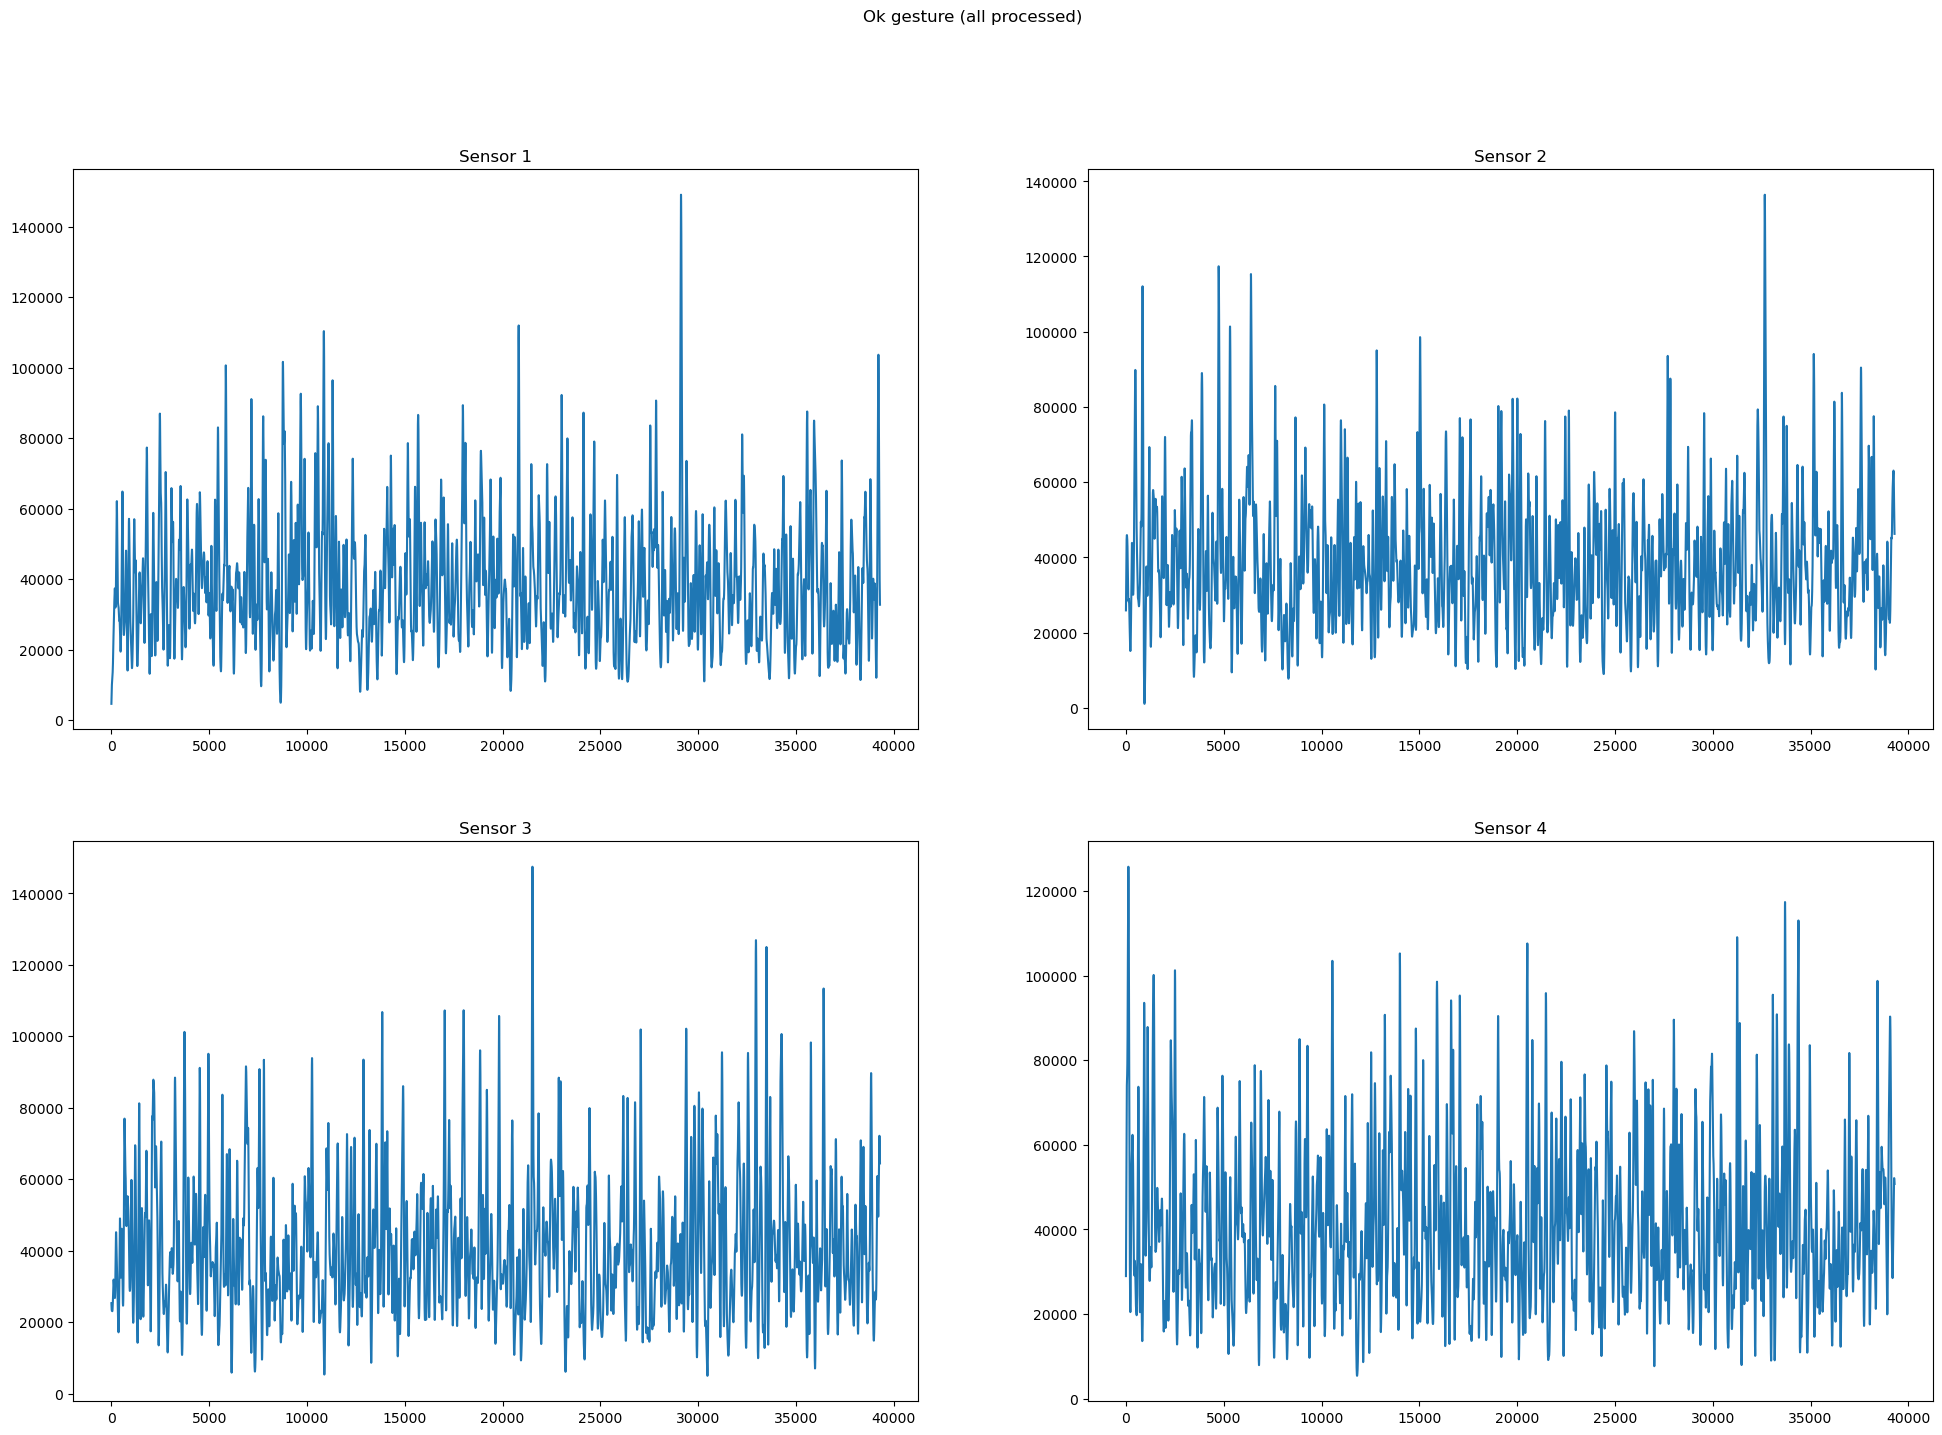

Baseline signal provided
Baseline noise:  90.75899940912764
Baseline noise:  90.83458252622388
Baseline noise:  90.80515165533176
Baseline noise:  90.80417800054809


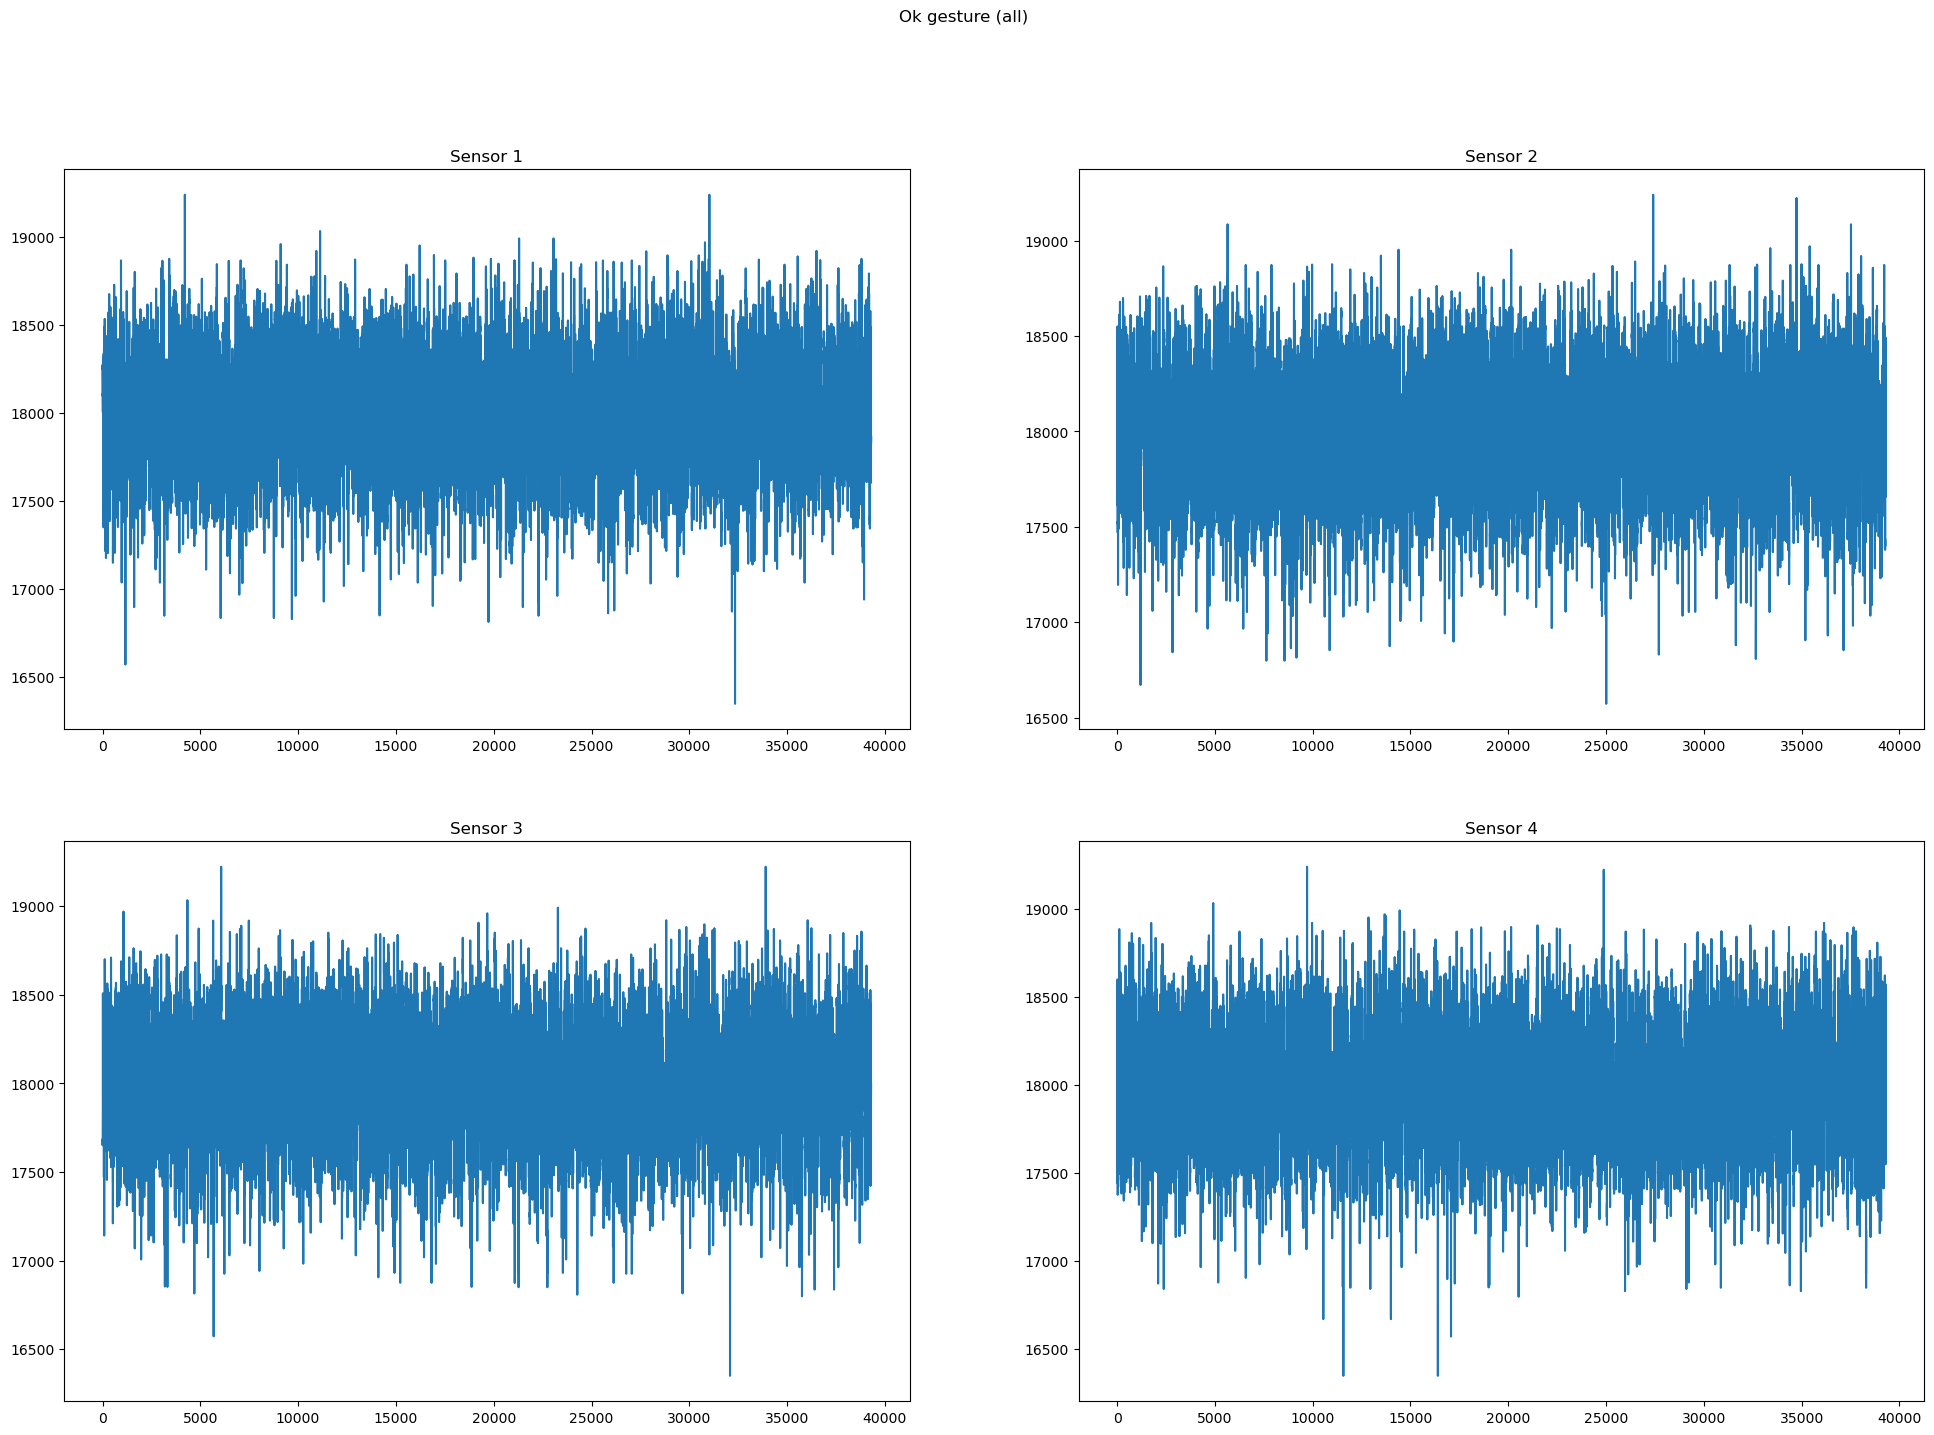

Raw SNR:  0.0024410947788936817


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.7019309787433285
Raw SNR:  -0.0030704757495634803
Processed SNR:  3.6642350621357296
Raw SNR:  -0.0006213175168224345


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.9927268430060723
Raw SNR:  -0.002001527022174812


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(


Processed SNR:  3.9512352683693788


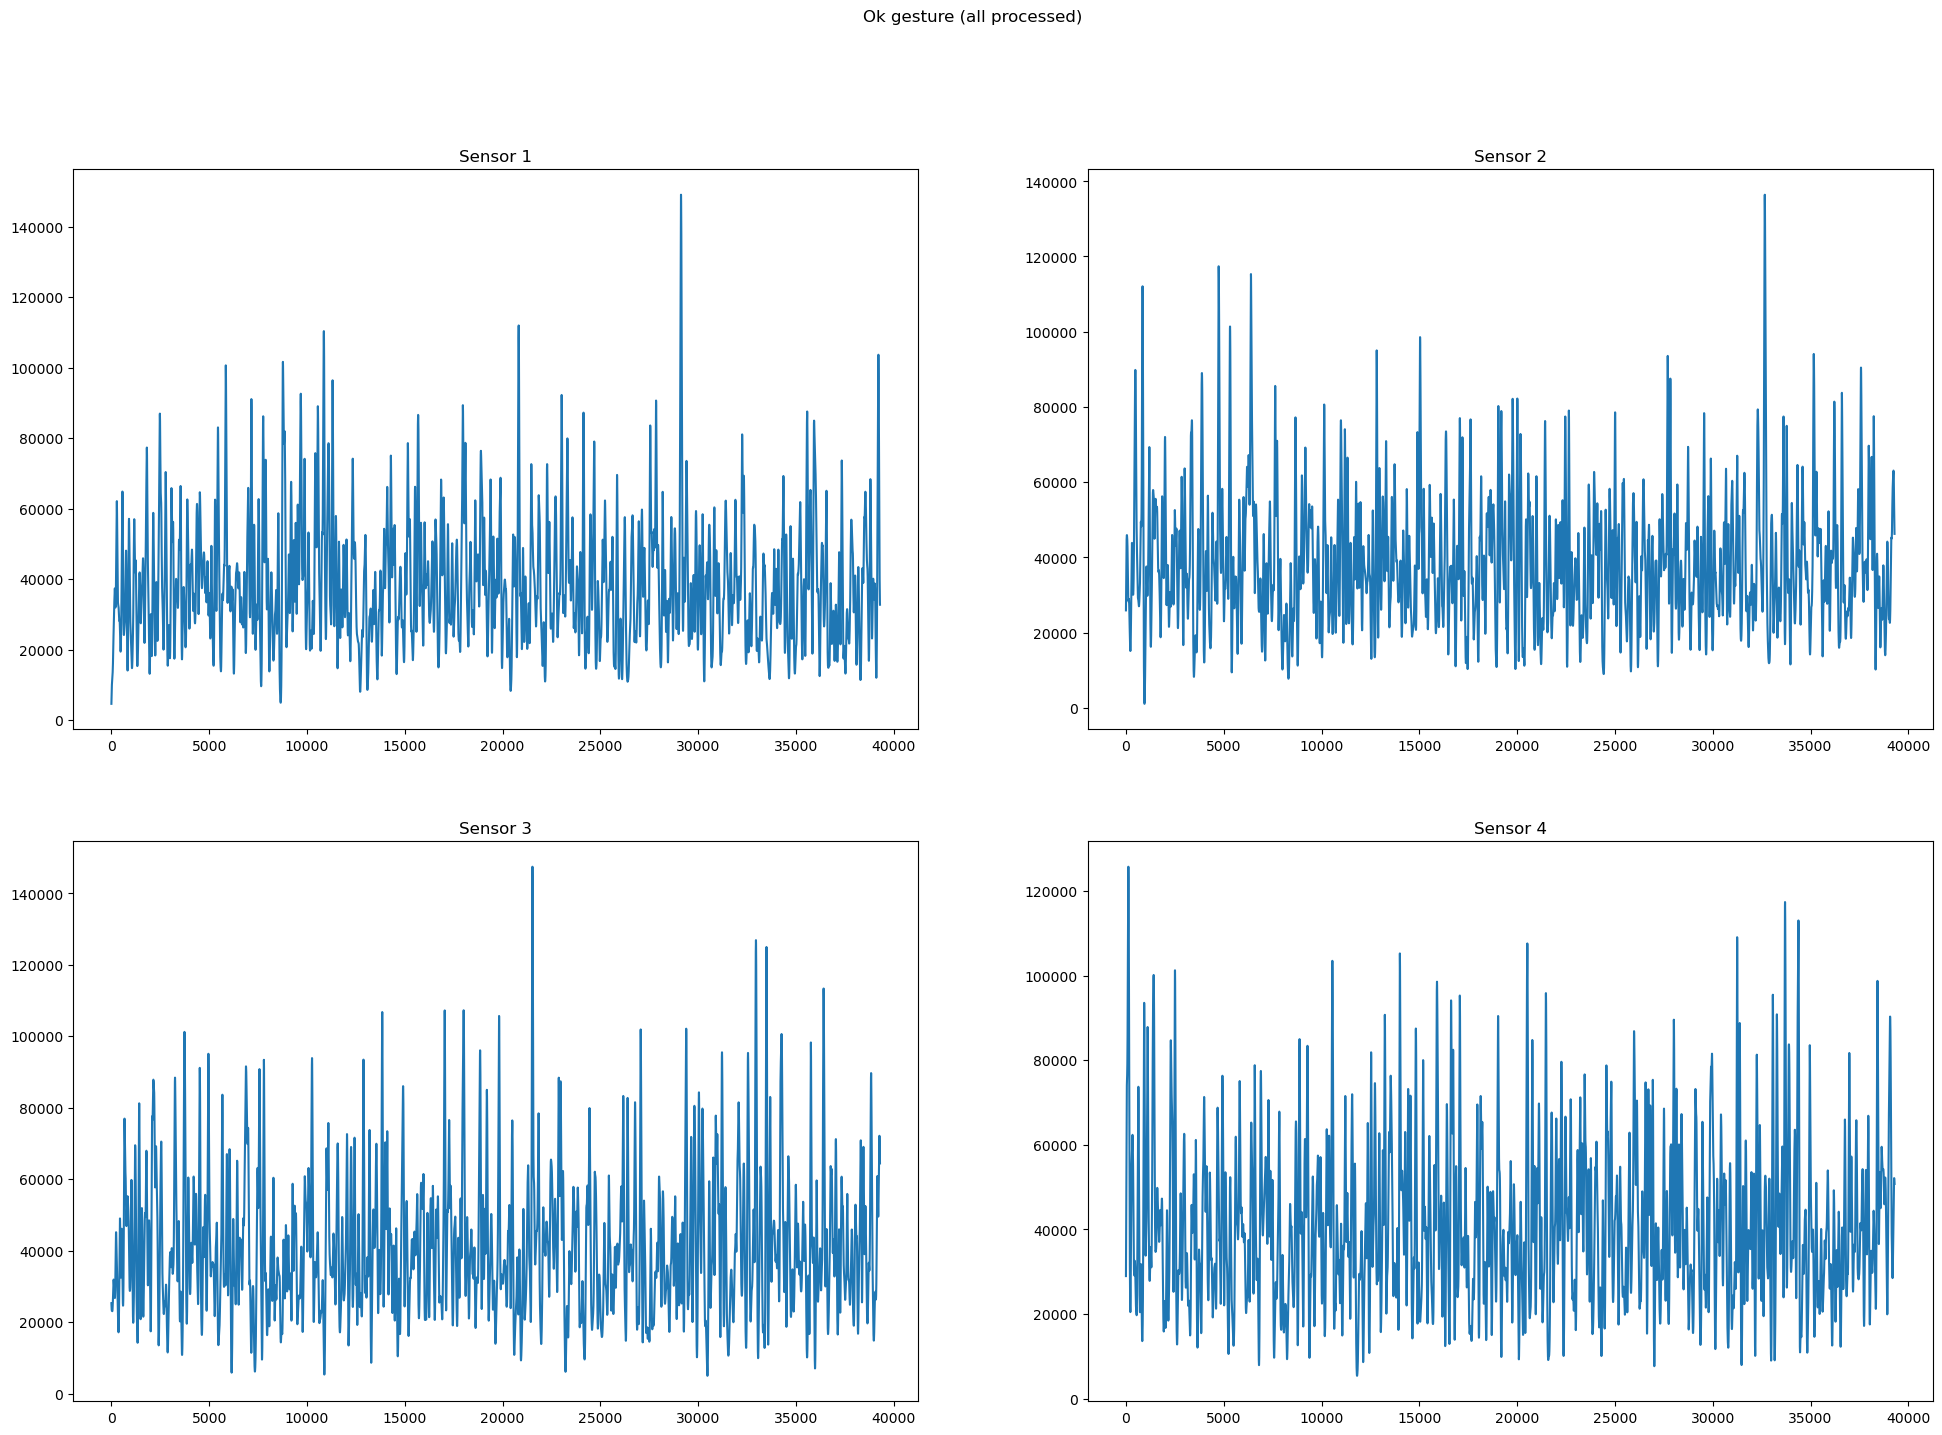

In [21]:
def plot_signal(data, row_index, title):
    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(data, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_signals(preprocessor, all_data, title, filter=False): 
    # Plot each sensor's signal
    signals = np.array_split(all_data, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        if filter:
            print('Raw SNR: ', preprocessor.signaltonoise(sigs, sensor))
            sigs = preprocessor.preprocess(sigs, sensor)
            print('Processed SNR: ', preprocessor.signaltonoise(sigs, sensor))

        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()

# index = 3
# raw_signal = fist_df.iloc[index, :-1].values
# plot_signal(raw_signal, row_index=index, title='Fist gesture')
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.values, filter_type='band', library='scipy')
# proc_data = preprocessor.preprocess(raw_signal)
# plot_signal(proc_data, row_index=index, title='Fist gesture (processed)')

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)
# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='scipy')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='nk2')
raw_signal = ok_df.iloc[:, :-1].values
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='nk2')
raw_signal = ok_df.iloc[:, :-1].values
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all)', filter=False)
plot_all_signals(preprocessor, raw_signal, title='Ok gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='highlow', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

# preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='libemg')
# raw_signal = fist_df.iloc[:, :-1].values
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all)', filter=False)
# plot_all_signals(preprocessor, raw_signal, title='Fist gesture (all processed)', filter=True)

## Class distribution

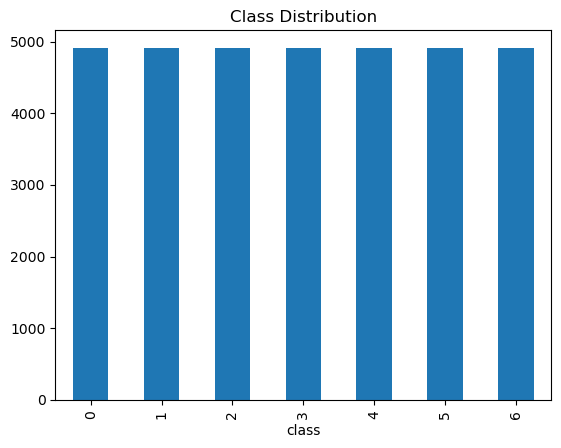

In [86]:
df.iloc[:, -1].value_counts().plot(kind='bar', title="Class Distribution")
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_182347/515862046.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()


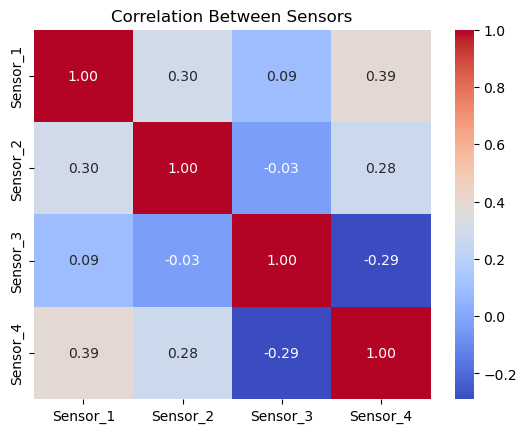

In [87]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 8, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(4)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

## Dimensionality Reduction

In [14]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=2)
shape = sensor_data.shape
signals = np.array_split(sensor_data, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs

sensor_preproc = np.asarray(signals).flatten().reshape(shape)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
plt.figure(figsize=(10, 5))
for class_id in np.unique(labels):
    plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
plt.title("PCA Dimensionality Reduction")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

# # t-SNE Dimensionality Reduction to 2 components
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_result = tsne.fit_transform(sensor_preproc)

# # Plot t-SNE results
# plt.figure(figsize=(10, 5))
# for class_id in np.unique(labels):
#     plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
# plt.title("t-SNE Dimensionality Reduction")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
# plt.show()

/home/madnad/anaconda3/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


NameError: name 'preprocessor' is not defined

## Data Preprocessing

## Spectal Analysis

In [ ]:
preprocess = True

def spectral_analysis_overall(dataframe):
    time_steps_per_sensor = dataframe.shape[1] // num_sensors

    # Separate gesture class and sensor data
    gesture_classes = dataframe.iloc[:, -1]
    sensor_data = dataframe.iloc[:, :-1]
    
    # Prepare to store FFT results for each sensor
    fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}

    # Loop over all rows and accumulate FFT results per sensor
    for index, row in sensor_data.iterrows():
        signals = np.array_split(row.values, num_sensors)
        for i, signal in enumerate(signals):
            if preprocess:
                signal = preprocess_data(signal)
            fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]  # Positive frequencies only
            fft_results[f'Sensor_{i+1}'].append(fft_result)
    
    # Compute average FFT amplitude for each sensor
    avg_fft_results = {sensor: np.mean(fft_results[sensor], axis=0) for sensor in fft_results}

    # Plot average FFT for each sensor
    plt.figure(figsize=(15, 10))
    for sensor, avg_fft in avg_fft_results.items():
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]  # Positive frequencies
        plt.plot(freqs, avg_fft, label=sensor)
    
    plt.title("Average Spectral Analysis for All Sensors")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Now analyze by gesture class
    unique_classes = np.unique(gesture_classes)
    plt.figure(figsize=(15, 10))
    for gesture_class in unique_classes:
        class_subset = dataframe[dataframe.iloc[:, -1] == gesture_class]
        class_fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}
        for _, row in class_subset.iloc[:, :-1].iterrows():
            signals = np.array_split(row.values, num_sensors)
            for i, signal in enumerate(signals):
                if preprocess:
                    signal = preprocess_data(signal)
                fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]
                class_fft_results[f'Sensor_{i+1}'].append(fft_result)
        # Average across this class
        avg_class_fft = np.mean([np.mean(class_fft_results[sensor], axis=0) for sensor in class_fft_results], axis=0)
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]
        plt.plot(freqs, avg_class_fft, label=f"Class {gesture_class}")

    plt.title("Average Spectral Analysis by Gesture Class")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
spectral_analysis_overall(df)

## Train networks

In [22]:
preprocessor = EMG_preprocessor(lf, hf, fs, trim, bandpass_order, outlier_rejection_stds, neutral_df.iloc[:, :-1].values, filter_type='band', library='nk2')

raw_signal = neutral_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
neutral_df = pd.DataFrame(raw_signal)
neutral_df['class'] = Classes.NEUTRAL

raw_signal = fist_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
fist_df = pd.DataFrame(raw_signal)
fist_df['class'] = Classes.FIST

raw_signal = index_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
index_df = pd.DataFrame(raw_signal)
index_df['class'] = Classes.INDEX

raw_signal = middle_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
middle_df = pd.DataFrame(raw_signal)
middle_df['class'] = Classes.MIDDLE

raw_signal = ok_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
ok_df = pd.DataFrame(raw_signal)
ok_df['class'] = Classes.OK

raw_signal = peace_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
peace_df = pd.DataFrame(raw_signal)
peace_df['class'] = Classes.PEACE

raw_signal = thumb_df.iloc[:, :-1].values
shape = raw_signal.shape
signals = np.array_split(raw_signal, num_sensors)
for sensor in range(0, num_sensors):
    sigs = signals[sensor]
    sigs = np.array(sigs).flatten()
    sigs = preprocessor.preprocess(sigs, sensor)
    signals[sensor] = sigs
raw_signal = np.asarray(signals).flatten().reshape(shape)
thumb_df = pd.DataFrame(raw_signal)
thumb_df['class'] = Classes.THUMB

df = pd.concat([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)

print(df.head())
print(df.iloc[:, -1].value_counts())

Baseline signal provided
Baseline noise:  90.75899940912764
Baseline noise:  90.83458252622388
Baseline noise:  90.80515165533176
Baseline noise:  90.80417800054809


/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home/madnad/anaconda3/lib/python3.12/site-packages/neurokit2/events/events_find.py:152: NeuroKitWarning: No events found. Check your event_channel or adjust 'threshold' or 'keep' arguments.
  warn(
/home

              0             1             2             3             4  \
0 -9.526434e-26 -8.382038e-26 -7.258273e-26 -6.158980e-26 -5.087661e-26   
1  9.726513e-26  9.794653e-26  9.843002e-26  9.872756e-26  9.885056e-26   
2  6.359870e-26  6.176631e-26  5.993416e-26  5.810503e-26  5.628162e-26   
3  1.492899e-26  1.394786e-26  1.300417e-26  1.209760e-26  1.122783e-26   
4 -1.007644e-27 -1.134332e-27 -1.247941e-27 -1.349187e-27 -1.438761e-27   

              5             6             7             8             9  ...  \
0 -4.047376e-26 -3.040740e-26 -2.069956e-26 -1.136836e-26 -2.428324e-27  ...   
1  9.880985e-26  9.861564e-26  9.827762e-26  9.780496e-26  9.720634e-26  ...   
2  5.446649e-26  5.266208e-26  5.087072e-26  4.909463e-26  4.733591e-26  ...   
3  1.039444e-26  9.596941e-27  8.834818e-27  8.107479e-27  7.414287e-27  ...   
4 -1.517334e-27 -1.585551e-27 -1.644039e-27 -1.693399e-27 -1.734210e-27  ...   

             23            24            25            26           

In [23]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [24]:
X.max(), X.min()

(653832.4194838463, -6195.265693935725)

In [25]:
# scaler= RobustScaler()
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [26]:
with open("custom_scaler_transformed_features.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [27]:
X.max(), X.min()

(16.366617379488602, -1.0943706691259862)

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [29]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0, 1, 2, 3, 4, 5, 6]),
 array([ 978, 1000,  990,  985,  968,  978,  978]))

## Classical models

In [30]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', max_depth=100, random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=100, random_state=42)

In [31]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(44, 74)

In [32]:
with open("custom_classifier_transformed_features.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [33]:
y_pred = clf.predict(X_train)
print('Classification Report: \n', classification_report(y_train, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3934
           1       1.00      1.00      1.00      3912
           2       1.00      1.00      1.00      3922
           3       1.00      1.00      1.00      3927
           4       1.00      1.00      1.00      3944
           5       1.00      1.00      1.00      3934
           6       1.00      1.00      1.00      3934

    accuracy                           1.00     27507
   macro avg       1.00      1.00      1.00     27507
weighted avg       1.00      1.00      1.00     27507

Confusion Matrix: 
 [[3934    0    0    0    0    0    0]
 [   0 3912    0    0    0    0    0]
 [   0    0 3922    0    0    0    0]
 [   0    0    0 3927    0    0    0]
 [   0    0    0    0 3944    0    0]
 [   0    0    0    0    0 3934    0]
 [   0    0    0    0    0    0 3934]]


In [34]:
y_pred = clf.predict(X_test)

In [35]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       978
           1       0.47      0.46      0.46      1000
           2       0.20      0.20      0.20       990
           3       0.20      0.21      0.20       985
           4       0.18      0.18      0.18       968
           5       0.20      0.19      0.19       978
           6       0.18      0.19      0.18       978

    accuracy                           0.35      6877
   macro avg       0.35      0.35      0.35      6877
weighted avg       0.35      0.35      0.35      6877

Confusion Matrix: 
 [[978   0   0   0   0   0   0]
 [  0 455  84  94 141  95 131]
 [  0  94 199 192 152 189 164]
 [  0  73 200 203 150 189 170]
 [  0 141 147 153 177 150 200]
 [  0  78 201 195 160 190 154]
 [  0 134 142 167 195 158 182]]


In [ ]:

lr_grid = {'max_depth' : [4, 8, 16, 32, 64, 128],
           'criterion' : ['entropy', 'gini']}

clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

gs = GridSearchCV(estimator=clf, param_grid=lr_grid, cv=5)
gs.fit(X_train, y_train)
y_pred = gs.predict(X_test)

In [ ]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

In [ ]:
with open("custom_classifier_gen2.pkl", "wb") as f:
    dump(gs, f, protocol=5)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Deep Learning

In [55]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(1024, 1024)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(1024, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.softmax(self.fc3(x), dim=1)
        return x

In [58]:
input_size = X_train.shape[1]
output_size = 7
batch_size = 64
epochs = 200
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

ff_model = NeuralNet(input_size, output_size)
criterion = nn.CrossEntropyLoss()  # Sparse categorical cross-entropy
optimizer = optim.Adam(ff_model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ff_model.to(device)

NeuralNet(
  (fc1): Linear(in_features=32, out_features=1024, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=1024, out_features=7, bias=True)
)

In [ ]:
batch_size = 256

In [ ]:
for epoch in range(epochs):
    ff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = ff_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute running loss and accuracy
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step(running_loss / total)
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct / total * 100
    
    ff_model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        y_test_tensor = y_test_tensor.to(device)
        outputs = ff_model(X_test_tensor)
        _, predicted = outputs.max(1)
        test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

In [ ]:
torch.save(ff_model.state_dict(), 'custom_nn_transformed_features.pth')

In [ ]:
ff_model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    outputs = ff_model(X_test_tensor)
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

In [ ]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
gc.collect()

In [59]:
class PureLSTM(nn.Module):
    
    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes):
        super(PureLSTM, self).__init__()
        
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=n_hidden, num_layers=n_layers, batch_first=True)
        
        self.linear_1 = nn.Linear(in_features=n_hidden, out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)
        
        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)        
        
    
    def forward(self, x):
        
        self.hidden = (
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device)
        )
    
        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1),self.hidden)
        out = out[:,-1,:]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)
        
        return out
    
def train_model(model, train_dataloader, n_epochs):
    global X_test_tensor, y_test_tensor
    
    running_loss = 0.0
    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)
    
    for epoch in range(n_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step(running_loss / total)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct / total * 100
        
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            outputs = model(X_test_tensor)
            _, predicted = outputs.max(1)
            test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")
        
    return model

In [60]:
n_features = 32
n_sequence=1
# n_features = 4
# n_sequence=8
n_hidden=32*3
n_layers=2
epochs = 400

model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size).to(device)

print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
# X_train_tensor = X_train_tensor.view(-1, n_sequence, n_features)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model = train_model(model, train_loader, n_epochs = epochs)

Train Data Shape  (27507, 32) (27507,)
Test Data Shape  (6877, 32) (6877,)
Epoch 1/400, Loss: 1.7134, Accuracy: 26.93%, Test Accuracy: 30.26%
Epoch 2/400, Loss: 3.3407, Accuracy: 28.53%, Test Accuracy: 30.35%
Epoch 3/400, Loss: 4.9598, Accuracy: 29.20%, Test Accuracy: 30.33%
Epoch 4/400, Loss: 6.5755, Accuracy: 29.57%, Test Accuracy: 30.84%
Epoch 5/400, Loss: 8.1872, Accuracy: 29.84%, Test Accuracy: 30.59%
Epoch 6/400, Loss: 9.7979, Accuracy: 30.04%, Test Accuracy: 31.90%
Epoch 7/400, Loss: 11.4077, Accuracy: 30.18%, Test Accuracy: 31.58%
Epoch 8/400, Loss: 13.0168, Accuracy: 30.32%, Test Accuracy: 31.98%
Epoch 9/400, Loss: 14.6251, Accuracy: 30.39%, Test Accuracy: 31.77%
Epoch 10/400, Loss: 16.2322, Accuracy: 30.47%, Test Accuracy: 31.77%
Epoch 11/400, Loss: 17.8399, Accuracy: 30.53%, Test Accuracy: 30.52%
Epoch 12/400, Loss: 19.4467, Accuracy: 30.57%, Test Accuracy: 32.06%
Epoch 13/400, Loss: 21.0531, Accuracy: 30.63%, Test Accuracy: 31.44%
Epoch 14/400, Loss: 22.6577, Accuracy: 30.6

KeyboardInterrupt: 

In [ ]:
torch.save(model.state_dict(), 'custom_lstm_transformed_features.pth')

def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

In [ ]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature engineering